## `crossmatch.ipynb`
------------------------

This notebook does crossmatching between the sampled DESI catalog and HSC.

In [1]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

## to look at the distribution of target classes in DESI on the plot
from desitarget.targetmask import desi_mask

## file manager; replace with your own module if needed
import src.statistics.corrfiles as cf

In [5]:
# in case using LSS catalogs from DESI (though it is easier to use the zcatalog directly)
lsscats = True
sv3 = True
# For the HSC catalog, either use the compiled catalog made with make_hscy3.py (modified version) from this repo,
# or alternatively one can find the catalogs per patch in T. Zhang's directory : /pscratch/sd/z/ztq1996/HSCDATA/HSCY3 on NERSC.
# the command below is simply a wrapper to fetch the compiled catalog.
hsc_catalog = cf.fetch_hsc_files()
if lsscats and not sv3:
    # these are cross-matches with the DESI target classes from the LSS catalogs.
    # In order to look for cross-matches with the entire zcatalog from DESI, use the zcatalog instead.
    # Here, we use DR2. In DR2, ELGnotqso includes both LOP and VLO; this is not true in DR1, where only LOP is included :
    # to use DR1, change version="DR1" and use "ELG_LOPnotqso" instead of "ELGnotqso"
    tgts = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
    caps = ["SGC", "NGC"]
    desi_catalog = [
        cf.fetch_desi_files(
            tgt=t, cap=c, version="DR2", randoms=False, weight_type="PIP"
        )
        for t in tgts
        for c in caps
    ]
elif sv3 and lsscats:
    tgts = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
    desi_catalog = ["/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/"
                    + f"{tgt}_{s}_clustering.dat.fits" for tgt in tgts for s in ["N", "S"]]
else:
    # change this path to use fuji if using DR1 (instead of LOA)
    desi_catalog = ["/global/cfs/projectdirs/desi/public/dr2/spectro/redux/loa/zcatalog/v1/zall-pix-loa.fits"]
root = cf.get_base_dir()
xmatch_root = root / "data" / "xmatch"
print(f"HSC Catalog : {hsc_catalog}")
print(f"DESI Catalog : {desi_catalog}")
print(f"Saving cross-matched catalog to : {xmatch_root}")

HSC Catalog : /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits
DESI Catalog : ['/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/BGS_ANY_N_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/BGS_ANY_S_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/LRG_N_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/LRG_S_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/ELGnotqso_N_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/ELGnotqso_S_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/QSO_N_clustering.dat.fits', '/global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/QSO_S_clustering.dat.fits']
Saving cross-matched catalog to : /global/cfs/cdirs/desicollab/users/jchdj/de

In [3]:
# Read the HSC catalog
hsc = fio.read(hsc_catalog)

In [6]:
from astropy.table import Table, vstack

desi_arr = []

for cat in desi_catalog:
    t = Table.read(cat) 
    t = t[["TARGETID", "RA", "DEC", "Z"]]
    for tgt in tgts:
        if tgt in str(cat):
            print(f"tgt {tgt}, {cat}")
            t['GAL_TYPE'] = np.full(len(t), tgt)
    desi_arr.append(t)

desi = vstack(desi_arr)

tgt BGS_ANY, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/BGS_ANY_N_clustering.dat.fits
tgt BGS_ANY, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/BGS_ANY_S_clustering.dat.fits
tgt LRG, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/LRG_N_clustering.dat.fits
tgt LRG, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/LRG_S_clustering.dat.fits
tgt ELGnotqso, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/ELGnotqso_N_clustering.dat.fits
tgt ELGnotqso, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/ELGnotqso_S_clustering.dat.fits
tgt QSO, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/QSO_N_clustering.dat.fits
tgt QSO, /global/cfs/projectdirs/desi/survey/catalogs/SV3/LSS/fuji/LSScats/3.1/QSO_S_clustering.dat.fits


In [7]:
print("Loading HSC coordinates ...")
coords_hsc = SkyCoord(ra=hsc["ra"], dec=hsc["dec"], unit=(u.deg, u.deg), frame="icrs")
print("Loading DESI coordinates ...")
coords_desi = SkyCoord(
    ra=desi["RA"], dec=desi["DEC"], unit=(u.deg, u.deg), frame="icrs"
)

Loading HSC coordinates ...
Loading DESI coordinates ...


# Crossmatch the two catalogs

Syntax : 
`idx, d2d, _ = cat1.match_to_catalog_sky(cat2, **kwargs)`  

Returns : 
- `idx` : index of cat2 that are the closest entry to cat1
- `d2d` : angular separation between the two coordinates

Since HSC is much deeper than DESI, we can expect all DESI spectra in HSC's footprint to have a match in HSC. Outside of HSC's footprint, we'll have to exclude the matched rows of DESI.

In [8]:
# Perform the crossmatch, assuming HSC is deeper than DESI (ETA ~ 1min)
idx, d2d, _ = coords_desi.match_to_catalog_sky(coords_hsc)

In [9]:
# Setting a maximum separation of x arcsec between two targets when crossmatching
max_sep = 1 * u.arcsec
sep_constraint = d2d < max_sep

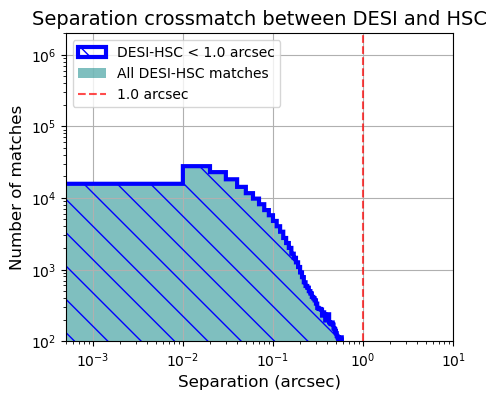

In [10]:
# Plotting separation histogram based on the crossmatch
plt.figure(figsize=(5, 4))
xmatch_bins = np.linspace(0, 50, 5000)
plt.hist(
    d2d[sep_constraint].arcsec,
    bins=xmatch_bins,
    alpha=1,
    histtype="step",
    color="blue",
    hatch="\\",
    linewidth=3,
    label=f"DESI-HSC < {max_sep}",
)
plt.hist(
    d2d.arcsec, bins=xmatch_bins, alpha=0.5, color="teal", label="All DESI-HSC matches"
)
plt.axvline(
    max_sep.to(u.arcsec).value,
    color="red",
    linestyle="--",
    label=f"{max_sep}",
    alpha=0.7,
)
plt.xlabel("Separation (arcsec)", fontsize=12)
plt.ylabel("Number of matches", fontsize=12)
plt.title("Separation crossmatch between DESI and HSC", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.xlim(5e-4, 1e1)
plt.ylim(1e2, 2e6)
plt.legend(fontsize=10, loc="upper left")
plt.grid()

In [11]:
# Getting the matched coordinates between the two catalogs
coords_xmatch_desi = coords_desi[sep_constraint]
coords_xmatch_hsc = coords_hsc[idx[sep_constraint]]
print(len(coords_xmatch_desi), "DESI targets matched with HSC")
print(len(coords_xmatch_hsc), "HSC targets matched with DESI")

177863 DESI targets matched with HSC
177863 HSC targets matched with DESI


In [12]:
## Saving output catalogs based on separation indices
desi_xmatch_file = Path(
    xmatch_root, f"desi_xm_hsc_sep{max_sep.to(u.arcsec).value}.fits"
)
hsc_xmatch_file = Path(xmatch_root, f"hsc_xm_desi_sep{max_sep.to(u.arcsec).value}.fits")

In [13]:
desi_xmatch = Table(desi[sep_constraint])
hsc_xmatch = Table(hsc[idx[sep_constraint]])

In [14]:
desi_xmatch["HSC_ROW_MATCH"] = idx[sep_constraint]
hsc_xmatch["DESI_ROW_MATCH"] = np.flatnonzero(sep_constraint)
# Save the matched catalogs
hsc_xmatch.write(hsc_xmatch_file, overwrite=True)
print(f"HSC matched catalog saved to {hsc_xmatch_file}")
desi_xmatch.write(desi_xmatch_file, overwrite=True)
print(f"DESI matched catalog saved to {desi_xmatch_file}")

HSC matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/hsc_xm_desi_sep1.0.fits
DESI matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/desi_xm_hsc_sep1.0.fits


In [15]:
ra_desi = coords_xmatch_desi.ra.rad
dec_desi = coords_xmatch_desi.dec.rad
ra_hsc = coords_xmatch_hsc.ra.rad
dec_hsc = coords_xmatch_hsc.dec.rad

Finished plotting DESI coordinates
Finished plotting HSC coordinates


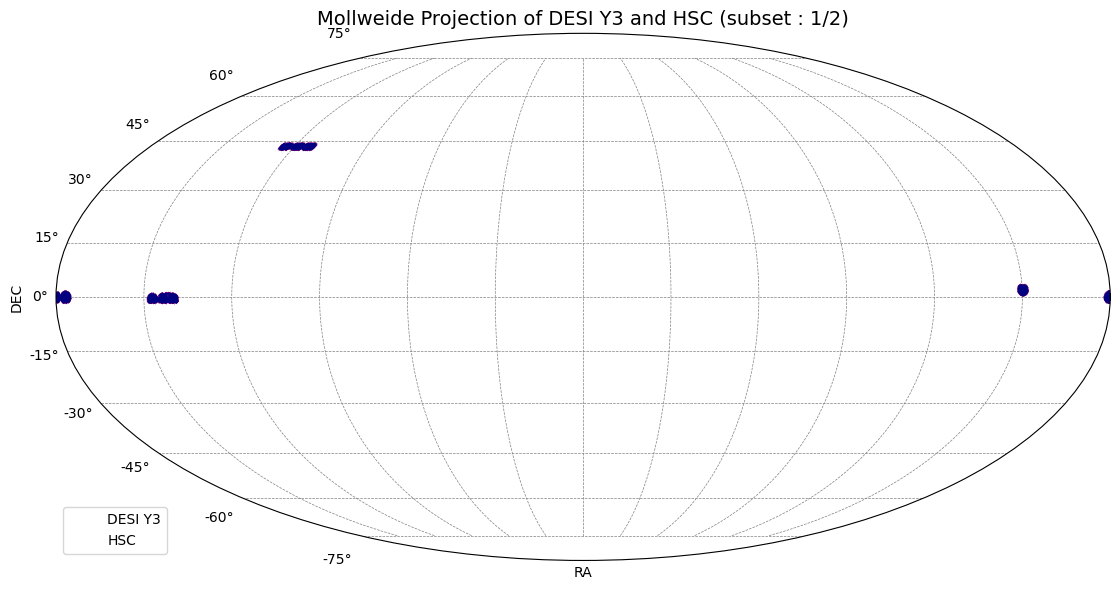

In [17]:
# Plotting the coordinates of the matched catalogs
sample_rate = 2
# Wrap RA coordinates to [-pi, pi]
ra_desi_wr = np.remainder(ra_desi[0::sample_rate] + np.pi, 2 * np.pi) - np.pi
ra_hsc_wr = np.remainder(ra_hsc[0::sample_rate] + np.pi, 2 * np.pi) - np.pi

plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection="mollweide")
ax.plot(
    ra_desi_wr,
    dec_desi[0::sample_rate],
    "r.",
    markersize=0.03,
    label="DESI Y3",
    alpha=0.3,
)
print(f"Finished plotting DESI coordinates")
ax.plot(
    ra_hsc_wr, dec_hsc[0::sample_rate], "b.", markersize=0.03, label="HSC", alpha=0.3
)
print(f"Finished plotting HSC coordinates")

ax.grid(color="gray", linestyle="--", linewidth=0.5)
ax.set_xticklabels([])
ax.legend(loc="lower left", fontsize=10)
ax.set_xlabel("RA")
ax.set_ylabel("DEC")
plt.title(
    f"Mollweide Projection of DESI Y3 and HSC (subset : 1/{sample_rate})", fontsize=14
)
plt.tight_layout()
plt.show()

In [53]:
## Let's zoom on a specifc region of the crossmatch
bounds = [
    [179, 181],  # RA
    [1, 3],  # DEC
]


def spatial_bounds(coords, bounds):
    """
    Function to select coordinates based on spatial bounds
    """
    ra = coords.ra.deg
    dec = coords.dec.deg
    mask = ((ra > bounds[0][0]) & (ra < bounds[0][1])) & (
        (dec > bounds[1][0]) & (dec < bounds[1][1])
    )
    return mask

In [54]:
# Compute xmatch bounded coords
desi_xmatch_coords_b = coords_xmatch_desi[spatial_bounds(coords_xmatch_desi, bounds)]
hsc_xmatch_coords_b = coords_xmatch_hsc[spatial_bounds(coords_xmatch_hsc, bounds)]

In [55]:
# Compute full sample bounded coords
desi_coords_b = coords_desi[spatial_bounds(coords_desi, bounds)]
hsc_coords_b = coords_hsc[spatial_bounds(coords_hsc, bounds)]

In [62]:
len(coords_xmatch_desi) / len(coords_hsc)

0.024064962995647924

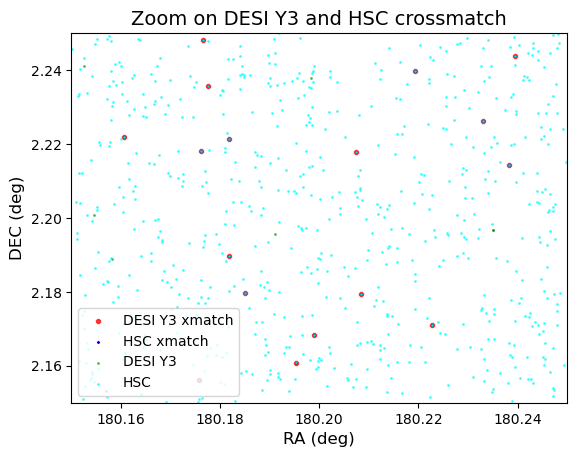

In [56]:
sample_rate_b = 4
center_ra = bounds[0][0] + (bounds[0][1] - bounds[0][0]) / 2
center_dec = bounds[1][0] + (bounds[1][1] - bounds[1][0]) / 2
zoom = 0.05
offset = 0.2
bds_ra = [center_ra - zoom + offset, center_ra + zoom + offset]
bds_dec = [center_dec - zoom + offset, center_dec + zoom + offset]
plt.xlim(bds_ra[0], bds_ra[1])
plt.ylim(bds_dec[0], bds_dec[1])


def set_range(coords, bds_x, bds_y):
    ra = coords.ra.deg
    dec = coords.dec.deg
    mask = ((ra > bds_x[0]) & (ra < bds_x[1])) & ((dec > bds_y[0]) & (dec < bds_y[1]))
    return ra[mask], dec[mask]


ra_desi_xmatch, dec_desi_xmatch = set_range(desi_xmatch_coords_b, bds_ra, bds_dec)
ra_hsc_xmatch, dec_hsc_xmatch = set_range(hsc_xmatch_coords_b, bds_ra, bds_dec)
ra_desi, dec_desi = set_range(desi_coords_b, bds_ra, bds_dec)
ra_hsc, dec_hsc = set_range(hsc_coords_b, bds_ra, bds_dec)

plt.scatter(
    ra_desi_xmatch,
    dec_desi_xmatch,
    color="red",
    marker="P",
    s=5,
    label="DESI Y3 xmatch",
    alpha=0.7,
)
plt.scatter(
    ra_hsc_xmatch,
    dec_hsc_xmatch,
    color="blue",
    marker="D",
    s=1,
    label="HSC xmatch",
    alpha=1,
)
plt.scatter(
    ra_desi, dec_desi, color="green", marker="X", s=1, label="DESI Y3", alpha=0.5
)
plt.scatter(ra_hsc, dec_hsc, color="cyan", marker="X", s=1, label="HSC", alpha=0.6)
plt.xlabel("RA (deg)", fontsize=12)
plt.ylabel("DEC (deg)", fontsize=12)
plt.title(f"Zoom on DESI Y3 and HSC crossmatch", fontsize=14)
plt.legend(loc="lower left", fontsize=10)

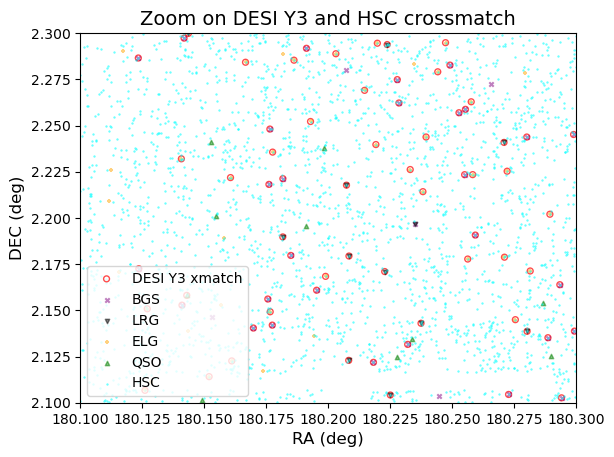

In [57]:
center_ra = bounds[0][0] + (bounds[0][1] - bounds[0][0]) / 2
center_dec = bounds[1][0] + (bounds[1][1] - bounds[1][0]) / 2
zoom = 0.1
offset = 0.2
bds_ra = [center_ra - zoom + offset, center_ra + zoom + offset]
bds_dec = [center_dec - zoom + offset, center_dec + zoom + offset]
plt.xlim(bds_ra[0], bds_ra[1])
plt.ylim(bds_dec[0], bds_dec[1])

ra_desi_xmatch, dec_desi_xmatch = set_range(desi_xmatch_coords_b, bds_ra, bds_dec)
ra_hsc_xmatch, dec_hsc_xmatch = set_range(hsc_xmatch_coords_b, bds_ra, bds_dec)
ra_desi, dec_desi = set_range(desi_coords_b, bds_ra, bds_dec)
ra_hsc, dec_hsc = set_range(hsc_coords_b, bds_ra, bds_dec)

plt.scatter(
    ra_desi_xmatch,
    dec_desi_xmatch,
    facecolors="none",
    edgecolors="red",
    linewidths=1,
    s=18,
    label="DESI Y3 xmatch",
    alpha=0.7,
    marker="o",
)

desi_tgt = desi["GAL_TYPE"][spatial_bounds(coords_desi, bounds)]

masks = {
    "BGS": desi_tgt == "BGS_ANY",
    "LRG": desi_tgt == "LRG",
    "ELG": desi_tgt == "ELGnotqso",
    "QSO": desi_tgt == "QSO",
    #'MWS': is_mws,
    #'SCND': is_scnd
}

colors = ["purple", "black", "orange", "green"]
markers = ["x", "v", "+", "^"]
for i, (key, mask) in enumerate(masks.items()):
    # print(f'Number of {key} targets : {len(desi[mask])}')
    ra_desi_mask, dec_desi_mask = set_range(desi_coords_b[mask], bds_ra, bds_dec)
    plt.scatter(
        ra_desi_mask,
        dec_desi_mask,
        marker=markers[i],
        s=10,
        color=colors[i],
        label=f"{key}",
        alpha=0.5,
    )
plt.scatter(ra_hsc, dec_hsc, color="cyan", marker="X", s=0.6, label="HSC", alpha=0.4)
plt.xlabel("RA (deg)", fontsize=12)
plt.ylabel("DEC (deg)", fontsize=12)
plt.title(f"Zoom on DESI Y3 and HSC crossmatch", fontsize=14)
plt.legend(loc="lower left", fontsize=10)